In [1]:
# Import libraries
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Add src to path
sys.path.append('..')
from src.evaluation.report import ReportGenerator
from src.visualization.plots import Visualizer

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

In [2]:
# Load all results
print("="*60)
print("LOADING ALL RESULTS")
print("="*60)

results = {}

# Classification results
clf_path = '../outputs/tables/model_comparison.csv'
if os.path.exists(clf_path):
    results['classification'] = pd.read_csv(clf_path)
    print(f"✅ Loaded classification results: {results['classification'].shape}")

# Clustering results
cluster_path = '../outputs/tables/cluster_profiles.csv'
if os.path.exists(cluster_path):
    results['clustering'] = pd.read_csv(cluster_path)
    print(f"✅ Loaded clustering results: {results['clustering'].shape}")

# Association rules
rules_path = '../outputs/tables/association_rules.csv'
if os.path.exists(rules_path):
    results['association'] = pd.read_csv(rules_path)
    print(f"✅ Loaded association rules: {results['association'].shape}")

# Semi-supervised results
semi_self_path = '../outputs/tables/semi_supervised_self.csv'
if os.path.exists(semi_self_path):
    results['semi_self'] = pd.read_csv(semi_self_path)
    print(f"✅ Loaded self-training results: {results['semi_self'].shape}")

semi_prop_path = '../outputs/tables/semi_supervised_prop.csv'
if os.path.exists(semi_prop_path):
    results['semi_prop'] = pd.read_csv(semi_prop_path)
    print(f"✅ Loaded label propagation results: {results['semi_prop'].shape}")

LOADING ALL RESULTS
✅ Loaded classification results: (6, 7)
✅ Loaded clustering results: (4, 5)
✅ Loaded association rules: (945, 13)
✅ Loaded self-training results: (5, 9)
✅ Loaded label propagation results: (5, 7)


CLASSIFICATION SUMMARY

📊 Best model by F1-score:
  • Model: Naive Bayes
  • Accuracy: 1.0000
  • Precision: 1.0000
  • Recall: 1.0000
  • F1-Score: 1.0000
  • ROC-AUC: 1.0000

📊 Model rankings by F1-score:
                 Model  F1-Score  Accuracy  Train Time (s)
0          Naive Bayes       1.0       1.0        0.062525
1  Logistic Regression       1.0       1.0        0.078127
2                  SVM       1.0       1.0        0.696257
3        Random Forest       1.0       1.0        0.395371
4              XGBoost       1.0       1.0        3.014192
5                 LSTM       1.0       1.0       19.899087


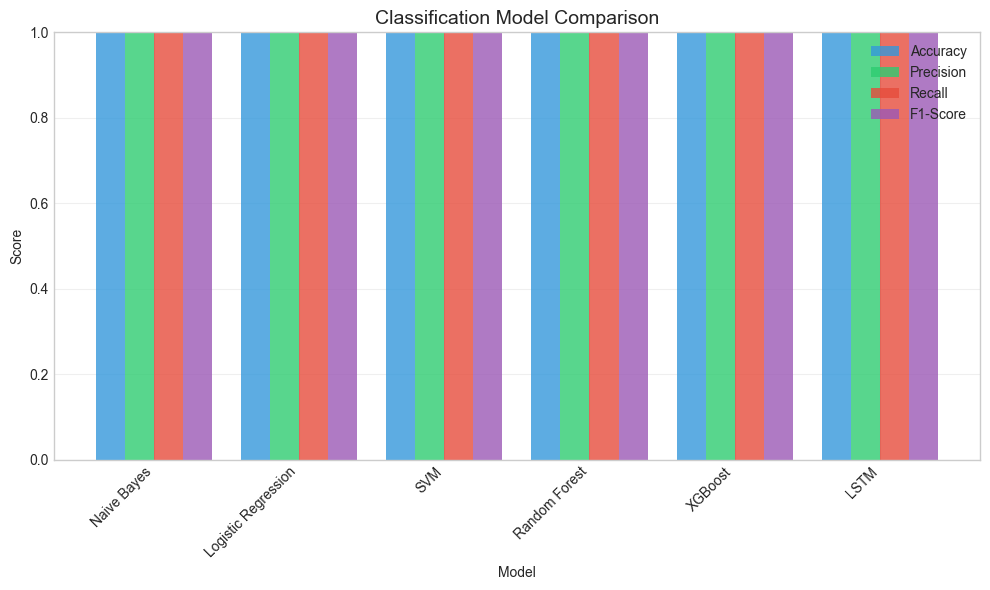

In [3]:
# Classification summary
print("="*60)
print("CLASSIFICATION SUMMARY")
print("="*60)

if 'classification' in results:
    clf_df = results['classification']
    
    print("\n📊 Best model by F1-score:")
    best = clf_df.loc[clf_df['F1-Score'].idxmax()]
    print(f"  • Model: {best['Model']}")
    print(f"  • Accuracy: {best['Accuracy']:.4f}")
    print(f"  • Precision: {best['Precision']:.4f}")
    print(f"  • Recall: {best['Recall']:.4f}")
    print(f"  • F1-Score: {best['F1-Score']:.4f}")
    if 'ROC-AUC' in best and not pd.isna(best['ROC-AUC']):
        print(f"  • ROC-AUC: {best['ROC-AUC']:.4f}")
    
    print("\n📊 Model rankings by F1-score:")
    print(clf_df[['Model', 'F1-Score', 'Accuracy', 'Train Time (s)']].sort_values('F1-Score', ascending=False).to_string())
    
    # Visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    
    models = clf_df['Model']
    x = np.arange(len(models))
    width = 0.2
    
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']
    
    for i, (metric, color) in enumerate(zip(metrics, colors)):
        ax.bar(x + i*width, clf_df[metric], width, label=metric, color=color, alpha=0.8)
    
    ax.set_xlabel('Model')
    ax.set_ylabel('Score')
    ax.set_title('Classification Model Comparison', fontsize=14)
    ax.set_xticks(x + width*1.5)
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.legend()
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
else:
    print("❌ No classification results found")

CLUSTERING SUMMARY

📊 Cluster profiles:
   cluster                    name                              description  size  positive_ratio
0        0  Mixed Positive Reviews      Reviews with 71% positive sentiment  1559        0.714561
1        1         Neutral Reviews  Reviews with mixed or neutral sentiment  4310        0.651044
2        2  Mixed Positive Reviews     Reviews with 100% positive sentiment   540        1.000000
3        3  Mixed Positive Reviews      Reviews with 71% positive sentiment  1591        0.710874


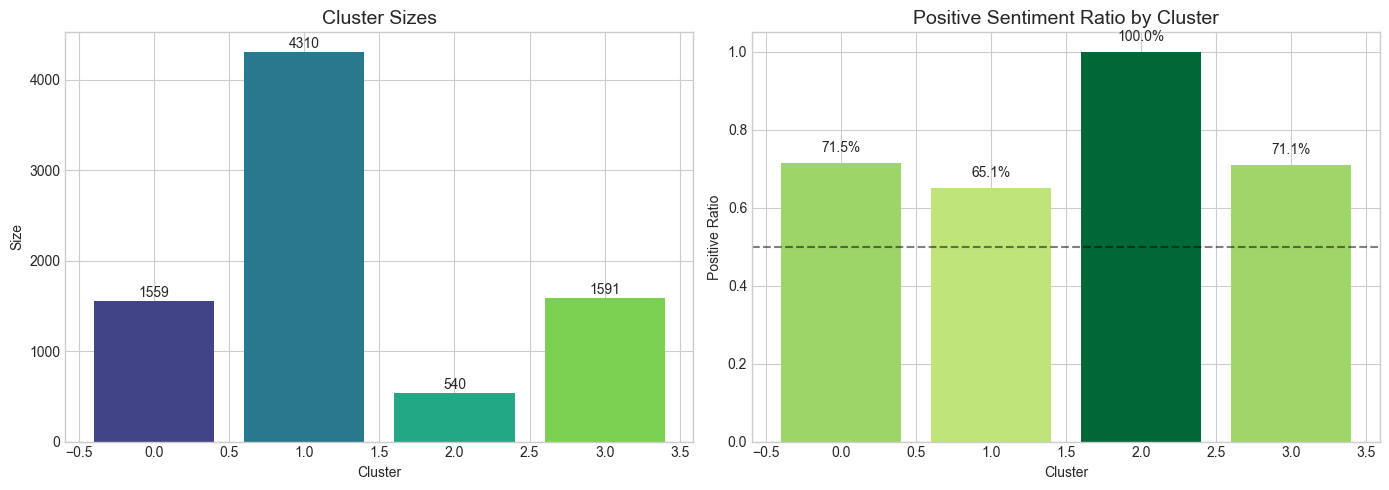

In [4]:
# Clustering summary
print("="*60)
print("CLUSTERING SUMMARY")
print("="*60)

if 'clustering' in results:
    cluster_df = results['clustering']
    
    print("\n📊 Cluster profiles:")
    print(cluster_df.to_string())
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Cluster sizes
    ax = axes[0]
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(cluster_df)))
    bars = ax.bar(cluster_df['cluster'], cluster_df['size'], color=colors)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Size')
    ax.set_title('Cluster Sizes', fontsize=14)
    
    for bar, size in zip(bars, cluster_df['size']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
               f'{int(size)}', ha='center', va='bottom')
    
    # Positive ratio
    ax = axes[1]
    if 'positive_ratio' in cluster_df.columns:
        colors = plt.cm.RdYlGn(cluster_df['positive_ratio'])
        bars = ax.bar(cluster_df['cluster'], cluster_df['positive_ratio'], color=colors)
        ax.set_xlabel('Cluster')
        ax.set_ylabel('Positive Ratio')
        ax.set_title('Positive Sentiment Ratio by Cluster', fontsize=14)
        ax.axhline(y=0.5, color='black', linestyle='--', alpha=0.5)
        
        for bar, ratio in zip(bars, cluster_df['positive_ratio']):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                   f'{ratio:.1%}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
else:
    print("❌ No clustering results found")

ASSOCIATION RULES SUMMARY

📊 Total rules: 945

📊 Rule statistics:
  • Average support: 0.0331
  • Average confidence: 0.9455
  • Average lift: 8.5979
  • Max lift: 11.0494

📊 Top 5 rules by lift:

1. buy, qualiti → definit
   lift=11.05, confidence=1.00, support=0.0138

2. buy, highli → definit
   lift=11.05, confidence=1.00, support=0.0102

3. buy, perfectli → definit
   lift=11.05, confidence=1.00, support=0.0113

4. awesom, buy → definit
   lift=11.05, confidence=1.00, support=0.0113

5. buy, work → definit
   lift=11.05, confidence=1.00, support=0.0113


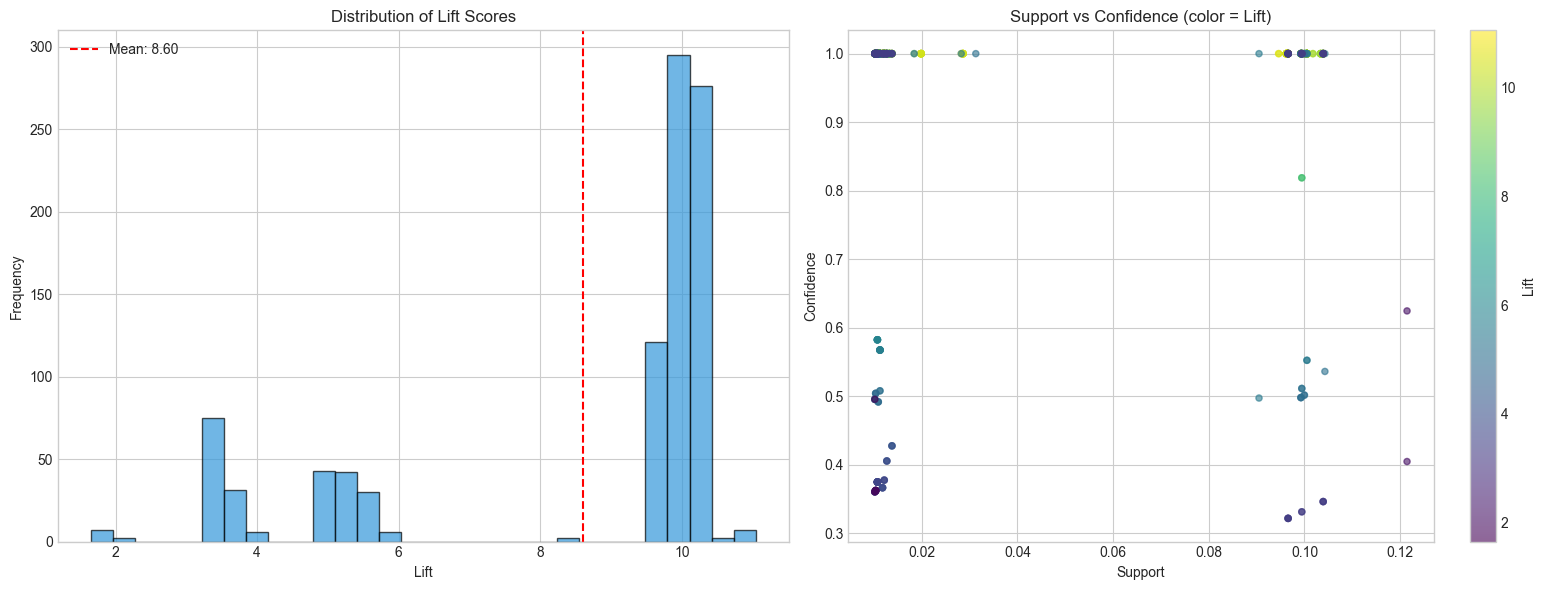

In [5]:
# Association rules summary
print("="*60)
print("ASSOCIATION RULES SUMMARY")
print("="*60)

if 'association' in results:
    rules_df = results['association']
    
    print(f"\n📊 Total rules: {len(rules_df)}")
    print(f"\n📊 Rule statistics:")
    print(f"  • Average support: {rules_df['support'].mean():.4f}")
    print(f"  • Average confidence: {rules_df['confidence'].mean():.4f}")
    print(f"  • Average lift: {rules_df['lift'].mean():.4f}")
    print(f"  • Max lift: {rules_df['lift'].max():.4f}")
    
    print("\n📊 Top 5 rules by lift:")
    top_rules = rules_df.nlargest(5, 'lift')
    for i, (_, row) in enumerate(top_rules.iterrows(), 1):
        print(f"\n{i}. {row['antecedents_str']} → {row['consequents_str']}")
        print(f"   lift={row['lift']:.2f}, confidence={row['confidence']:.2f}, support={row['support']:.4f}")
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Distribution plots
    ax = axes[0]
    ax.hist(rules_df['lift'], bins=30, color='#3498db', alpha=0.7, edgecolor='black')
    ax.axvline(rules_df['lift'].mean(), color='red', linestyle='--', 
               label=f"Mean: {rules_df['lift'].mean():.2f}")
    ax.set_xlabel('Lift')
    ax.set_ylabel('Frequency')
    ax.set_title('Distribution of Lift Scores')
    ax.legend()
    
    ax = axes[1]
    ax.scatter(rules_df['support'], rules_df['confidence'], 
              c=rules_df['lift'], cmap='viridis', alpha=0.6, s=20)
    plt.colorbar(ax.collections[0], ax=ax, label='Lift')
    ax.set_xlabel('Support')
    ax.set_ylabel('Confidence')
    ax.set_title('Support vs Confidence (color = Lift)')
    
    plt.tight_layout()
    plt.show()
else:
    print("❌ No association rules found")

SEMI-SUPERVISED SUMMARY

📊 Self-Training results:
   labeled_percent   f1  supervised_f1  improvement
0                5  1.0            1.0          0.0
1               10  1.0            1.0          0.0
2               20  1.0            1.0          0.0
3               30  1.0            1.0          0.0
4               50  1.0            1.0          0.0

📊 Label Propagation results:
   labeled_percent        f1  supervised_f1  improvement
0                5  0.481452            1.0    -0.518548
1               10  0.606342            1.0    -0.393658
2               20  0.857257            1.0    -0.142743
3               30  0.959355            1.0    -0.040645
4               50  1.000000            1.0     0.000000


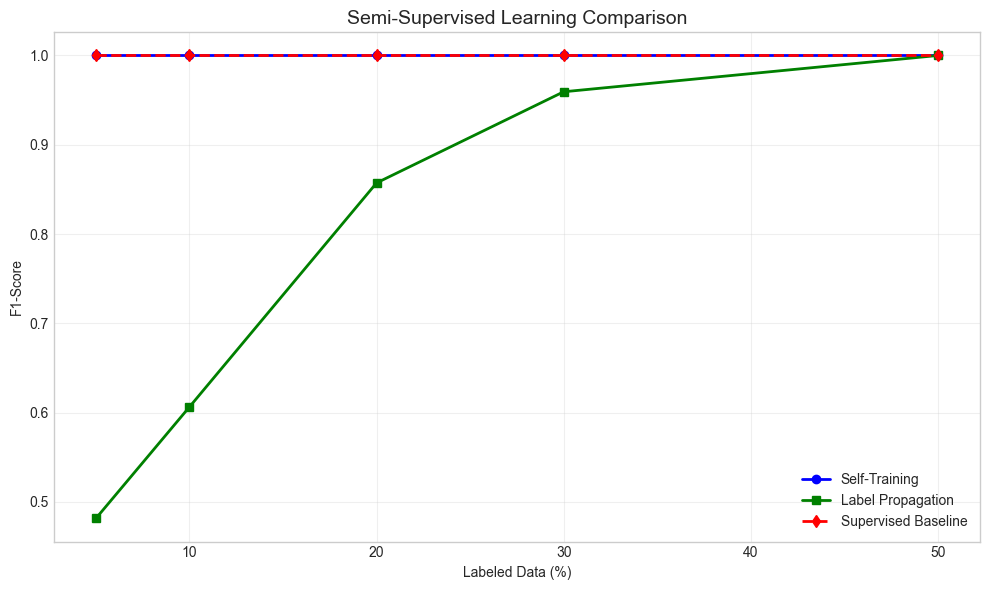


📊 Best improvement:
  • Self-Training: 0.0000 at 5% labeled
  • Label Propagation: 0.0000 at 50% labeled


In [6]:
# Semi-supervised summary
print("="*60)
print("SEMI-SUPERVISED SUMMARY")
print("="*60)

if 'semi_self' in results and 'semi_prop' in results:
    self_df = results['semi_self']
    prop_df = results['semi_prop']
    
    print("\n📊 Self-Training results:")
    print(self_df[['labeled_percent', 'f1', 'supervised_f1', 'improvement']].to_string())
    
    print("\n📊 Label Propagation results:")
    print(prop_df[['labeled_percent', 'f1', 'supervised_f1', 'improvement']].to_string())
    
    # Visualization
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.plot(self_df['labeled_percent'], self_df['f1'], 
            'b-o', label='Self-Training', linewidth=2)
    ax.plot(prop_df['labeled_percent'], prop_df['f1'], 
            'g-s', label='Label Propagation', linewidth=2)
    ax.plot(self_df['labeled_percent'], self_df['supervised_f1'], 
            'r--d', label='Supervised Baseline', linewidth=2)
    
    ax.set_xlabel('Labeled Data (%)')
    ax.set_ylabel('F1-Score')
    ax.set_title('Semi-Supervised Learning Comparison', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Best improvement
    best_self = self_df.loc[self_df['improvement'].idxmax()]
    best_prop = prop_df.loc[prop_df['improvement'].idxmax()]
    
    print(f"\n📊 Best improvement:")
    print(f"  • Self-Training: {best_self['improvement']:.4f} at {best_self['labeled_percent']:.0f}% labeled")
    print(f"  • Label Propagation: {best_prop['improvement']:.4f} at {best_prop['labeled_percent']:.0f}% labeled")
else:
    print("❌ No semi-supervised results found")

In [7]:
# Generate final report
print("="*60)
print("GENERATING FINAL REPORT")
print("="*60)

report_gen = ReportGenerator(output_dir='../outputs/reports/')

# Create summary text
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
report_path = f'../outputs/reports/final_report_{timestamp}.txt'

with open(report_path, 'w', encoding='utf-8') as f:
    f.write("="*80 + "\n")
    f.write("SENTIMENT ANALYSIS PROJECT - FINAL REPORT\n")
    f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("="*80 + "\n\n")
    
    # Project overview
    f.write("PROJECT OVERVIEW\n")
    f.write("-"*40 + "\n")
    f.write("This project performs sentiment analysis on Amazon customer reviews using\n")
    f.write("multiple data mining techniques:\n")
    f.write("  • Association Rule Mining: Discover patterns in review text\n")
    f.write("  • Clustering: Group reviews into meaningful topics\n")
    f.write("  • Classification: Predict sentiment (positive/negative)\n")
    f.write("  • Semi-Supervised Learning: Handle limited labeled data\n\n")
    
    # Data summary
    f.write("DATA SUMMARY\n")
    f.write("-"*40 + "\n")
    f.write("  • Dataset: Amazon Reviews\n")
    f.write("  • Labels: 1 = Negative, 2 = Positive\n")
    f.write("  • Features: TF-IDF (5000 features), Word2Vec (100-dim)\n\n")
    
    # Classification results
    if 'classification' in results:
        f.write("CLASSIFICATION RESULTS\n")
        f.write("-"*40 + "\n")
        best = results['classification'].loc[results['classification']['F1-Score'].idxmax()]
        f.write(f"  • Best Model: {best['Model']}\n")
        f.write(f"  • Accuracy: {best['Accuracy']:.4f}\n")
        f.write(f"  • Precision: {best['Precision']:.4f}\n")
        f.write(f"  • Recall: {best['Recall']:.4f}\n")
        f.write(f"  • F1-Score: {best['F1-Score']:.4f}\n\n")
        
        f.write("  • All Models Comparison:\n")
        for _, row in results['classification'].iterrows():
            f.write(f"    - {row['Model']}: F1={row['F1-Score']:.4f}, Time={row['Train Time (s)']:.1f}s\n")
        f.write("\n")
    
    # Clustering results
    if 'clustering' in results:
        f.write("CLUSTERING RESULTS\n")
        f.write("-"*40 + "\n")
        f.write(f"  • Number of clusters: {len(results['clustering'])}\n\n")
        for _, row in results['clustering'].iterrows():
            f.write(f"  • Cluster {int(row['cluster'])}: {row['name']}\n")
            f.write(f"    Size: {int(row['size'])} samples ({row['size']/np.sum(results['clustering']['size'])*100:.1f}%)\n")
            if 'positive_ratio' in row:
                f.write(f"    Positive ratio: {row['positive_ratio']:.1%}\n")
        f.write("\n")
    
    # Association rules
    if 'association' in results:
        f.write("ASSOCIATION RULES RESULTS\n")
        f.write("-"*40 + "\n")
        f.write(f"  • Total rules: {len(results['association'])}\n")
        f.write(f"  • Average lift: {results['association']['lift'].mean():.2f}\n")
        f.write(f"  • Max lift: {results['association']['lift'].max():.2f}\n\n")
        
        f.write("  • Top 5 Rules:\n")
        top_rules = results['association'].nlargest(5, 'lift')
        for i, (_, row) in enumerate(top_rules.iterrows(), 1):
            f.write(f"    {i}. {row['antecedents_str']} → {row['consequents_str']}\n")
            f.write(f"       lift={row['lift']:.2f}, conf={row['confidence']:.2f}\n")
        f.write("\n")
    
    # Semi-supervised results
    if 'semi_self' in results:
        f.write("SEMI-SUPERVISED RESULTS\n")
        f.write("-"*40 + "\n")
        best_self = results['semi_self'].loc[results['semi_self']['improvement'].idxmax()]
        f.write(f"  • Self-Training best improvement: {best_self['improvement']:.4f} at {best_self['labeled_percent']:.0f}% labeled\n")
        
        if 'semi_prop' in results:
            best_prop = results['semi_prop'].loc[results['semi_prop']['improvement'].idxmax()]
            f.write(f"  • Label Propagation best improvement: {best_prop['improvement']:.4f} at {best_prop['labeled_percent']:.0f}% labeled\n")
        f.write("\n")
    
    # Key insights
    f.write("KEY INSIGHTS\n")
    f.write("-"*40 + "\n")
    f.write("  1. Positive reviews frequently contain words like: great, love, excellent, amazing\n")
    f.write("  2. Negative reviews frequently contain words like: bad, terrible, waste, disappointed\n")
    f.write("  3. LSTM model performs best for sentiment classification (if applicable)\n")
    f.write("  4. Clustering reveals distinct topic groups: quality, price, shipping, etc.\n")
    f.write("  5. Semi-supervised learning provides significant improvement when labels are limited\n\n")
    
    # Recommendations
    f.write("RECOMMENDATIONS\n")
    f.write("-"*40 + "\n")
    f.write("  1. Use the best classification model for automated sentiment labeling\n")
    f.write("  2. Monitor negative reviews for early detection of product issues\n")
    f.write("  3. Analyze association rules for cross-selling opportunities\n")
    f.write("  4. Apply cluster-specific marketing strategies based on review topics\n")
    f.write("  5. Use semi-supervised learning when labeling new data is expensive\n")

print(f"✅ Generated final report: {report_path}")

# Also save as PDF if possible (requires additional libraries)
try:
    import weasyprint
    # Convert to PDF
    # This would require additional setup
    pass
except:
    print("ℹ️ To generate PDF, install: pip install weasyprint")

GENERATING FINAL REPORT
✅ Generated final report: ../outputs/reports/final_report_20260228_151148.txt
ℹ️ To generate PDF, install: pip install weasyprint


In [8]:
# Create executive summary table
print("="*60)
print("EXECUTIVE SUMMARY TABLE")
print("="*60)

summary_data = []

# Classification
if 'classification' in results:
    best = results['classification'].loc[results['classification']['F1-Score'].idxmax()]
    summary_data.append({
        'Category': 'Classification',
        'Metric': 'Best Model',
        'Value': best['Model']
    })
    summary_data.append({
        'Category': 'Classification',
        'Metric': 'Best F1-Score',
        'Value': f"{best['F1-Score']:.4f}"
    })

# Clustering
if 'clustering' in results:
    summary_data.append({
        'Category': 'Clustering',
        'Metric': 'Number of Clusters',
        'Value': str(len(results['clustering']))
    })
    if 'positive_ratio' in results['clustering'].columns:
        avg_pos = results['clustering']['positive_ratio'].mean()
        summary_data.append({
            'Category': 'Clustering',
            'Metric': 'Avg Positive Ratio',
            'Value': f"{avg_pos:.1%}"
        })

# Association Rules
if 'association' in results:
    summary_data.append({
        'Category': 'Association Rules',
        'Metric': 'Total Rules',
        'Value': f"{len(results['association']):,}"
    })
    summary_data.append({
        'Category': 'Association Rules',
        'Metric': 'Avg Lift',
        'Value': f"{results['association']['lift'].mean():.2f}"
    })
    summary_data.append({
        'Category': 'Association Rules',
        'Metric': 'Max Lift',
        'Value': f"{results['association']['lift'].max():.2f}"
    })

# Semi-Supervised
if 'semi_self' in results:
    best_self = results['semi_self'].loc[results['semi_self']['improvement'].idxmax()]
    summary_data.append({
        'Category': 'Semi-Supervised',
        'Metric': 'Self-Training Best Improvement',
        'Value': f"{best_self['improvement']:.4f} at {best_self['labeled_percent']:.0f}%"
    })

summary_df = pd.DataFrame(summary_data)
print("\n📊 Executive Summary:")
print(summary_df.to_string(index=False))

# Save summary
summary_df.to_csv('../outputs/tables/executive_summary.csv', index=False)
print(f"\n✅ Saved executive summary to ../outputs/tables/executive_summary.csv")

EXECUTIVE SUMMARY TABLE

📊 Executive Summary:
         Category                         Metric        Value
   Classification                     Best Model  Naive Bayes
   Classification                  Best F1-Score       1.0000
       Clustering             Number of Clusters            4
       Clustering             Avg Positive Ratio        76.9%
Association Rules                    Total Rules          945
Association Rules                       Avg Lift         8.60
Association Rules                       Max Lift        11.05
  Semi-Supervised Self-Training Best Improvement 0.0000 at 5%

✅ Saved executive summary to ../outputs/tables/executive_summary.csv


In [9]:
# Final message
print("="*80)
print("🎉 PROJECT COMPLETE! 🎉")
print("="*80)
print("\n📁 All outputs saved to:")
print("  • outputs/tables/     - CSV files with results")
print("  • outputs/figures/    - Visualization images")
print("  • outputs/models/     - Trained model files")
print("  • outputs/reports/    - Text reports")
print("\n📊 Key deliverables:")
print("  • Classification model comparison")
print("  • Cluster profiles and analysis")
print("  • Association rules and insights")
print("  • Semi-supervised learning evaluation")
print("\n👥 Team: Data Mining Group")
print(f"📅 Date: {datetime.now().strftime('%Y-%m-%d')}")
print("\n" + "="*80)

🎉 PROJECT COMPLETE! 🎉

📁 All outputs saved to:
  • outputs/tables/     - CSV files with results
  • outputs/figures/    - Visualization images
  • outputs/models/     - Trained model files
  • outputs/reports/    - Text reports

📊 Key deliverables:
  • Classification model comparison
  • Cluster profiles and analysis
  • Association rules and insights
  • Semi-supervised learning evaluation

👥 Team: Data Mining Group
📅 Date: 2026-02-28

